# Hex-level DAG-style correlation analysis with demographic controls

This notebook extends the existing correlation work by adding a confounder-aware lens.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().resolve().parents[1]
MERGED_PATH = ROOT / "data/processed/crime_infrastructure_hex_merged.csv"
MODEL_PATH = ROOT / "data/processed/modeling/chicago_hex_modeling_table.csv"

print(MERGED_PATH)
print(MODEL_PATH)

/Users/buttz/Desktop/projects/gun-violence-analysis/data/processed/crime_infrastructure_hex_merged.csv
/Users/buttz/Desktop/projects/gun-violence-analysis/data/processed/modeling/chicago_hex_modeling_table.csv


In [2]:
merged = pd.read_csv(MERGED_PATH)
model = pd.read_csv(MODEL_PATH)

# Normalize historical/duplicate crime labels to canonical names.
crime_aliases = {
    "crim_sexual_assault": "criminal_sexual_assault",
}
for source_col, target_col in crime_aliases.items():
    if source_col in merged.columns:
        if target_col in merged.columns:
            merged[target_col] = merged[target_col].fillna(0) + merged[source_col].fillna(0)
        else:
            merged[target_col] = merged[source_col]
        merged = merged.drop(columns=[source_col])

socio_cols = ["hex_id", "community_area_number", "poverty_pct", "per_capita_income", "hardship_index"]
df = merged.merge(model[socio_cols], on="hex_id", how="left")

print("Rows in merged table:", len(merged))
print("Rows with socioeconomic fields after join:", df["per_capita_income"].notna().sum())
print("Rows missing socioeconomic fields:", df["per_capita_income"].isna().sum())
print("Crime aliases applied:", crime_aliases)

df = df.dropna(subset=["per_capita_income", "poverty_pct", "hardship_index"]).copy()
print("Complete-case rows used in analysis:", len(df))

Rows in merged table: 1778
Rows with socioeconomic fields after join: 1524
Rows missing socioeconomic fields: 254
Crime aliases applied: {'crim_sexual_assault': 'criminal_sexual_assault'}
Complete-case rows used in analysis: 1524


In [3]:
def spearman_corr(frame: pd.DataFrame, x: str, y: str) -> float:
    sub = frame[[x, y]].dropna()
    return float(stats.spearmanr(sub[x], sub[y]).correlation)


def partial_spearman(frame: pd.DataFrame, x: str, y: str, controls: list[str]) -> float:
    cols = [x, y] + controls
    sub = frame[cols].dropna()
    if len(sub) < 30:
        return np.nan

    # Spearman partial correlation via inverse correlation matrix (precision matrix)
    corr = sub.corr(method="spearman").values
    corr = corr + np.eye(corr.shape[0]) * 1e-10

    try:
        precision = np.linalg.inv(corr)
    except np.linalg.LinAlgError:
        precision = np.linalg.pinv(corr)

    i, j = 0, 1
    r_xy_controls = -precision[i, j] / np.sqrt(precision[i, i] * precision[j, j])
    return float(np.clip(r_xy_controls, -1, 1))

In [4]:
controls = ["per_capita_income", "poverty_pct", "hardship_index"]

# Match report scope:
# - crimes: all crime count columns except homicide and total_crime
# - infrastructure: all columns prefixed with infra_
crime_vars = [
    c
    for c in merged.columns
    if c not in {"hex_id", "homicide", "total_crime"} and not c.startswith("infra_")
]
infra_vars = [c for c in merged.columns if c.startswith("infra_")]

crime_rows = []
for v in sorted(crime_vars):
    if v not in df.columns:
        continue
    crime_rows.append(
        {
            "variable": v,
            "spearman_naive": spearman_corr(df, v, "homicide"),
            "partial_spearman_controls": partial_spearman(df, v, "homicide", controls),
            "delta": np.nan,
            "n_hex_present": int((df[v] > 0).sum()),
            "total_incidents_or_features": float(df[v].sum()),
        }
    )

infra_rows = []
for v in sorted(infra_vars):
    if v not in df.columns:
        continue
    infra_rows.append(
        {
            "variable": v,
            "spearman_naive": spearman_corr(df, v, "homicide"),
            "partial_spearman_controls": partial_spearman(df, v, "homicide", controls),
            "delta": np.nan,
            "n_hex_present": int((df[v] > 0).sum()),
            "total_incidents_or_features": float(df[v].sum()),
        }
    )

crime_res = pd.DataFrame(crime_rows)
infra_res = pd.DataFrame(infra_rows)

for frame in (crime_res, infra_res):
    frame["delta"] = frame["partial_spearman_controls"] - frame["spearman_naive"]

crime_res = crime_res.sort_values("spearman_naive", ascending=False).reset_index(drop=True)
infra_res = infra_res.sort_values("spearman_naive", ascending=False).reset_index(drop=True)

print("crime vars:", len(crime_res), "infra vars:", len(infra_res))
crime_res.head(10)

crime vars: 28 infra vars: 35


,variable,spearman_naive,partial_spearman_controls,delta,n_hex_present,total_incidents_or_features
0,weapons_violation,0.889446,0.820856,-0.068590,1471,125962.0
1,narcotics,0.856512,0.789637,-0.066876,1499,752758.0
2,battery,0.856145,0.814076,-0.042068,1510,1541143.0
3,assault,0.854264,0.812327,-0.041937,1505,568312.0
4,offense_involving_children,0.816693,0.751618,-0.065075,1438,56357.0
5,robbery,0.814337,0.774110,-0.040227,1475,314441.0
6,interference_with_public_officer,0.813469,0.733425,-0.080045,1315,20514.0
7,other_offense,0.800416,0.770857,-0.029559,1502,524411.0
8,criminal_sexual_assault,0.792302,0.754291,-0.038011,1436,36630.0
9,criminal_damage,0.791240,0.772515,-0.018725,1507,958539.0


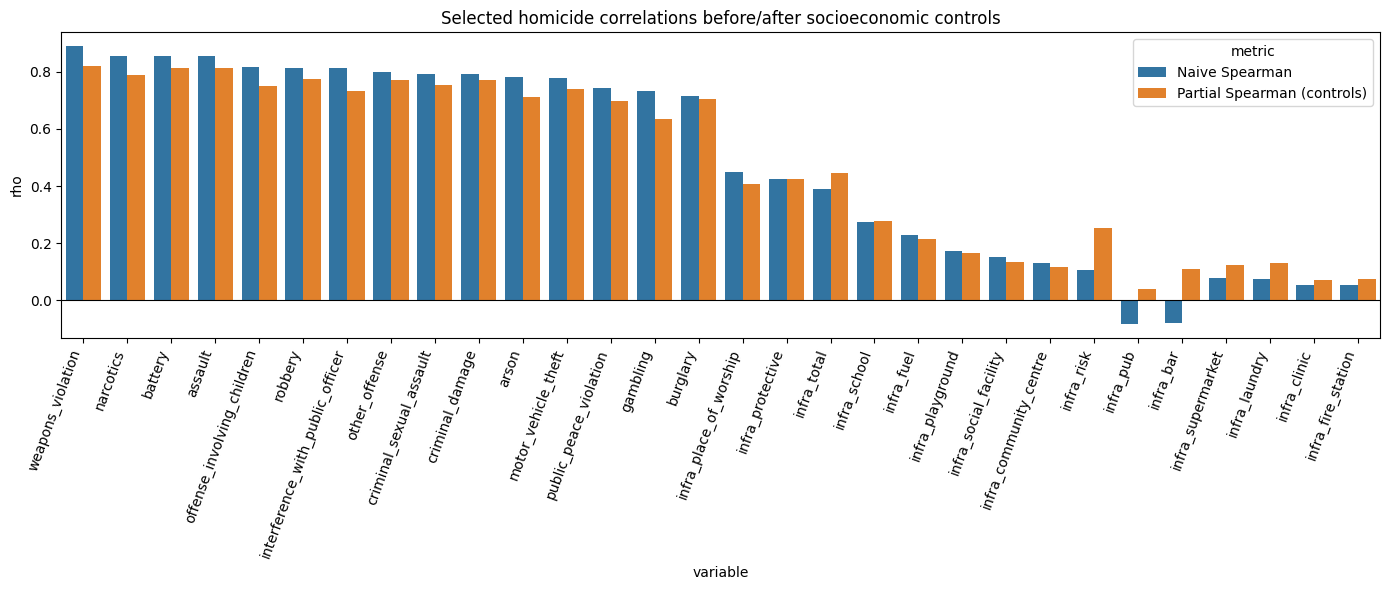

In [5]:
top_n = 15
plot_source = pd.concat(
    [
        crime_res.nlargest(top_n, "spearman_naive").assign(group="crime"),
        infra_res.reindex(infra_res["spearman_naive"].abs().sort_values(ascending=False).index)
        .head(top_n)
        .assign(group="infrastructure"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(14, 6))
plot_df = plot_source.melt(
    id_vars=["variable", "group"],
    value_vars=["spearman_naive", "partial_spearman_controls"],
    var_name="metric",
    value_name="rho",
)
plot_df["metric"] = plot_df["metric"].replace(
    {
        "spearman_naive": "Naive Spearman",
        "partial_spearman_controls": "Partial Spearman (controls)",
    }
)

sns.barplot(data=plot_df, x="variable", y="rho", hue="metric")
plt.axhline(0, color="black", lw=0.8)
plt.xticks(rotation=70, ha="right")
plt.title("Selected homicide correlations before/after socioeconomic controls")
plt.tight_layout()
plt.savefig("../../reports/figures/hex_dag_partial_spearman_crime_vs_homicide.png")
plt.show()

In [6]:
for c in ["per_capita_income", "poverty_pct", "hardship_index"]:
    print(c, "vs homicide Spearman:", round(spearman_corr(df, c, "homicide"), 3))

OUT_DIR = ROOT / "reports" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
crime_out = OUT_DIR / "dag_partial_spearman_crime_vs_homicide.csv"
infra_out = OUT_DIR / "dag_partial_spearman_infra_vs_homicide.csv"

crime_res.to_csv(crime_out, index=False)
infra_res.to_csv(infra_out, index=False)
print("wrote:", crime_out)
print("wrote:", infra_out)

crime_res.head(8), infra_res.head(8)

per_capita_income vs homicide Spearman: -0.524
poverty_pct vs homicide Spearman: 0.566
hardship_index vs homicide Spearman: 0.482
wrote: /Users/buttz/Desktop/projects/gun-violence-analysis/reports/figures/dag_partial_spearman_crime_vs_homicide.csv
wrote: /Users/buttz/Desktop/projects/gun-violence-analysis/reports/figures/dag_partial_spearman_infra_vs_homicide.csv


(                           variable  spearman_naive  \
 0                 weapons_violation        0.889446   
 1                         narcotics        0.856512   
 2                           battery        0.856145   
 3                           assault        0.854264   
 4        offense_involving_children        0.816693   
 5                           robbery        0.814337   
 6  interference_with_public_officer        0.813469   
 7                     other_offense        0.800416   
 
    partial_spearman_controls     delta  n_hex_present  \
 0                   0.820856 -0.068590           1471   
 1                   0.789637 -0.066876           1499   
 2                   0.814076 -0.042068           1510   
 3                   0.812327 -0.041937           1505   
 4                   0.751618 -0.065075           1438   
 5                   0.774110 -0.040227           1475   
 6                   0.733425 -0.080045           1315   
 7                   0.770857 

## Recommended DAG interpretation

Use this as your working causal sketch:

- `Neighborhood disadvantage` (latent; proxied by income/poverty/hardship) influences:
  - `homicide`
  - `narcotics`, `assault`, `battery`, `robbery`, `weapons violations`
  - where infrastructure is sited (`schools`, `churches`, etc.)
- Some crime variables may still have a direct path to `homicide` (e.g., weapons prevalence), but you should estimate those effects **conditional on socioeconomic context**.

In practical terms: report both naive and adjusted correlations, and avoid causal language unless you move to a design with temporal or quasi-experimental identification.